### 1.3.2.5. Derivatives of Activation Functions

$$
\sigma(x) = \frac{1}{1 + e^{-x}}, \quad \sigma'(x) = \sigma(x)\big(1 - \sigma(x)\big);
\qquad
\frac{d}{dx}\tanh x = 1 - \tanh^{2} x ;
$$

$$
\zeta(x) = \ln\!\big(1 + e^{x}\big), \quad \zeta'(x) = \sigma(x);
\qquad
\mathrm{ReLU}(x) = \max(0, x), \quad \mathrm{ReLU}'(x) = \begin{cases} 0, & x < 0 \\ 1, & x > 0 \end{cases}.
$$

**Explanation:**

Activation functions are the elementwise nonlinearities of neural networks, and their derivatives are exactly what the [chain rule](./03_chain_rule.ipynb) propagates during backpropagation. The logistic sigmoid and $\tanh$ have the convenient property that their derivatives are expressible in the activation's own output, so a forward pass already stores what the backward pass needs. Softplus is a smooth approximation to ReLU whose derivative is precisely the sigmoid, and ReLU itself has a constant-piece derivative that is cheap and avoids vanishing gradients (with a subgradient chosen at the kink $x = 0$).

**Properties:**
- $\sigma'(x) = \sigma(x)(1 - \sigma(x)) \le \tfrac14$, the source of the "vanishing gradient" of deep sigmoid stacks.
- $\tanh x = 2\sigma(2x) - 1$, so $\tanh$ is a rescaled sigmoid and is zero-centred.

**Numerical Example:**

Derive $\sigma'$ from the definition using the quotient/chain rule on $\sigma(x) = (1 + e^{-x})^{-1}$:

$$
\sigma'(x) = -\big(1 + e^{-x}\big)^{-2}\cdot(-e^{-x}) = \frac{e^{-x}}{(1 + e^{-x})^2}.
$$

Rewrite using $\sigma$: since $1 - \sigma(x) = \dfrac{e^{-x}}{1 + e^{-x}}$,

$$
\sigma'(x) = \frac{1}{1 + e^{-x}}\cdot\frac{e^{-x}}{1 + e^{-x}} = \sigma(x)\big(1 - \sigma(x)\big).
$$

At $x = 0$: $\sigma(0) = \tfrac12$, so $\sigma'(0) = \tfrac12\cdot\tfrac12 = \tfrac14$, the maximum slope of the sigmoid.

In [1]:
import sympy as sp

x = sp.symbols("x", real=True)
sigmoid = 1 / (1 + sp.exp(-x))
softplus = sp.log(1 + sp.exp(x))

sigmoid_derivative = sp.cancel(sp.diff(sigmoid, x))
sigmoid_identity = sp.simplify(sp.diff(sigmoid, x) - sigmoid * (1 - sigmoid))
tanh_identity = sp.simplify(sp.diff(sp.tanh(x), x) - (1 - sp.tanh(x)**2))
softplus_derivative = sp.simplify(sp.diff(softplus, x))
softplus_is_sigmoid = sp.simplify(softplus_derivative - sigmoid)

print("sigma'(x)                    =", sigmoid_derivative)
print("sigma'(x) - sigma(1-sigma)   =", sigmoid_identity)
print("sigma'(0)                    =", sp.diff(sigmoid, x).subs(x, 0))
print("d/dx tanh x - (1 - tanh^2 x) =", tanh_identity)
print("softplus'(x) - sigma(x)      =", softplus_is_sigmoid)

sigma'(x)                    = exp(x)/(exp(2*x) + 2*exp(x) + 1)
sigma'(x) - sigma(1-sigma)   = 0
sigma'(0)                    = 1/4
d/dx tanh x - (1 - tanh^2 x) = 0
softplus'(x) - sigma(x)      = 0


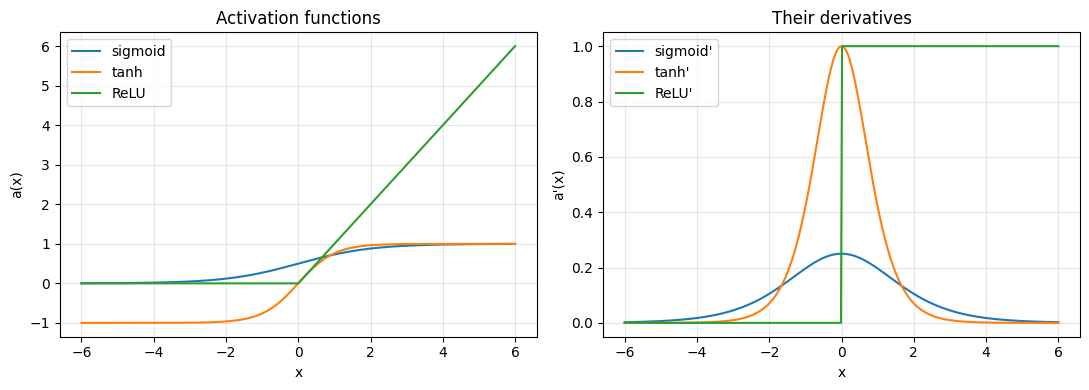

In [2]:
import numpy as np
import matplotlib.pyplot as plt

inputs = np.linspace(-6, 6, 400)
sigmoid_values = 1 / (1 + np.exp(-inputs))
sigmoid_slope = sigmoid_values * (1 - sigmoid_values)
tanh_values = np.tanh(inputs)
relu_values = np.maximum(0, inputs)

fig, (activation_axis, derivative_axis) = plt.subplots(1, 2, figsize=(11, 4))
activation_axis.plot(inputs, sigmoid_values, label="sigmoid")
activation_axis.plot(inputs, tanh_values, label="tanh")
activation_axis.plot(inputs, relu_values, label="ReLU")
activation_axis.set_title("Activation functions"); activation_axis.legend(); activation_axis.grid(True, alpha=0.3)
activation_axis.set_xlabel("x"); activation_axis.set_ylabel("a(x)")

derivative_axis.plot(inputs, sigmoid_slope, label="sigmoid'")
derivative_axis.plot(inputs, 1 - tanh_values**2, label="tanh'")
derivative_axis.plot(inputs, (inputs > 0).astype(float), label="ReLU'")
derivative_axis.set_title("Their derivatives"); derivative_axis.legend(); derivative_axis.grid(True, alpha=0.3)
derivative_axis.set_xlabel("x"); derivative_axis.set_ylabel("a'(x)")
plt.tight_layout(); plt.show()

**References:**

[📘 Strang, G. (2016). *Calculus Volume 1*. OpenStax.](https://openstax.org/details/books/calculus-volume-1)

---

[⬅️ Previous: Derivatives of Elementary Functions](./04_derivatives_of_elementary_functions.ipynb) | [Next: Higher-Order Derivatives ➡️](./06_higher_order_derivatives.ipynb)